# NetworkX: The Density Falloff
### Pinpointing exactly where NetworkX slows down and SciPy takes over


In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
    "networkx", "scipy", "numpy", "matplotlib"])

import time, gc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import networkx as nx
import scipy.sparse as sp

N = 1000
p_vals = np.linspace(0.01, 0.50, 30)
nx_ms, sp_ms, densities, edge_counts = [], [], [], []

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

def bench(func, *args, **kwargs):
    t0 = time.perf_counter()
    func(*args, **kwargs)
    return (time.perf_counter() - t0) * 1000

def scipy_pagerank(A, alpha=0.85, tol=1e-6, max_iter=100):
    n = A.shape[0]
    deg = np.array(A.sum(axis=1)).flatten()
    deg[deg == 0] = 1
    M = (sp.diags(1.0 / deg) @ A).T.tocsr()
    r = np.full(n, 1.0 / n)
    for _ in range(max_iter):
        r_new = alpha * (M @ r) + (1 - alpha) / n
        if np.linalg.norm(r_new - r, 1) < tol: break
        r = r_new
    return r

print("Ready.")

Ready.


---
## Section 1 — Fine-Grained Falloff Scan

We sweep density from 0.01 to 0.50 in small steps at N=1000.
Every step runs PageRank in both NetworkX and SciPy and records time and memory.
The crossover point — where SciPy first becomes faster — is marked precisely.


In [3]:
N = 1000
p_vals = np.linspace(0.01, 0.50, 30)

nx_ms, sp_ms = [], []
nx_kb, sp_kb = [], []
densities, edge_counts = [], []

print(f"Scanning {len(p_vals)} density steps at N={N}...")
print(f"{'density':>9}  {'edges':>7}  {'nx_ms':>8}  {'scipy_ms':>9}  {'faster':>8}")

for p in p_vals:
    G = nx.erdos_renyi_graph(N, p, seed=42)
    A = nx.to_scipy_sparse_array(G, dtype=float, format="csr")
    d = nx.density(G)

    t_nx = bench(nx.pagerank, G)
    t_sp = bench(scipy_pagerank, A)

    nx_ms.append(t_nx)
    sp_ms.append(t_sp)
    densities.append(d)
    edge_counts.append(G.number_of_edges())

    winner = "scipy ✓" if t_sp < t_nx else "nx    ✓"
    print(f"{d:>9.4f}  {G.number_of_edges():>7,}  {t_nx:>7.1f}ms  {t_sp:>8.1f}ms  {winner}")

    del G, A
    gc.collect()

nx_ms = np.array(nx_ms); sp_ms = np.array(sp_ms)
nx_kb = np.array(nx_kb); sp_kb = np.array(sp_kb)
densities = np.array(densities)

# Find crossover
crossover_idx = np.argmax(sp_ms < nx_ms)
crossover_density = densities[crossover_idx]
print(f"Crossover at density ≈ {crossover_density:.3f}  "
      f"({edge_counts[crossover_idx]:,} edges)")

Scanning 30 density steps at N=1000...
  density    edges     nx_ms   scipy_ms    faster
   0.0100    4,985     12.5ms       3.0ms  scipy ✓
   0.0266   13,295     17.8ms       1.5ms  scipy ✓
   0.0435   21,708     36.9ms       2.1ms  scipy ✓
   0.0603   30,132     39.8ms       2.5ms  scipy ✓
   0.0774   38,645     51.6ms       2.9ms  scipy ✓
   0.0944   47,168     62.7ms       3.4ms  scipy ✓
   0.1115   55,682     72.8ms       3.8ms  scipy ✓
   0.1283   64,101     86.5ms       4.4ms  scipy ✓
   0.1455   72,700     97.2ms       4.8ms  scipy ✓
   0.1621   80,991    109.4ms       5.3ms  scipy ✓
   0.1790   89,401    137.3ms       5.7ms  scipy ✓
   0.1959   97,875    132.5ms       6.3ms  scipy ✓
   0.2125  106,164    147.1ms       6.5ms  scipy ✓
   0.2292  114,497    156.5ms       6.8ms  scipy ✓
   0.2460  122,898    168.4ms       7.3ms  scipy ✓
   0.2630  131,380    181.3ms       7.9ms  scipy ✓
   0.2798  139,767    193.6ms       8.2ms  scipy ✓
   0.2967  148,224    204.7ms       8.7ms  s

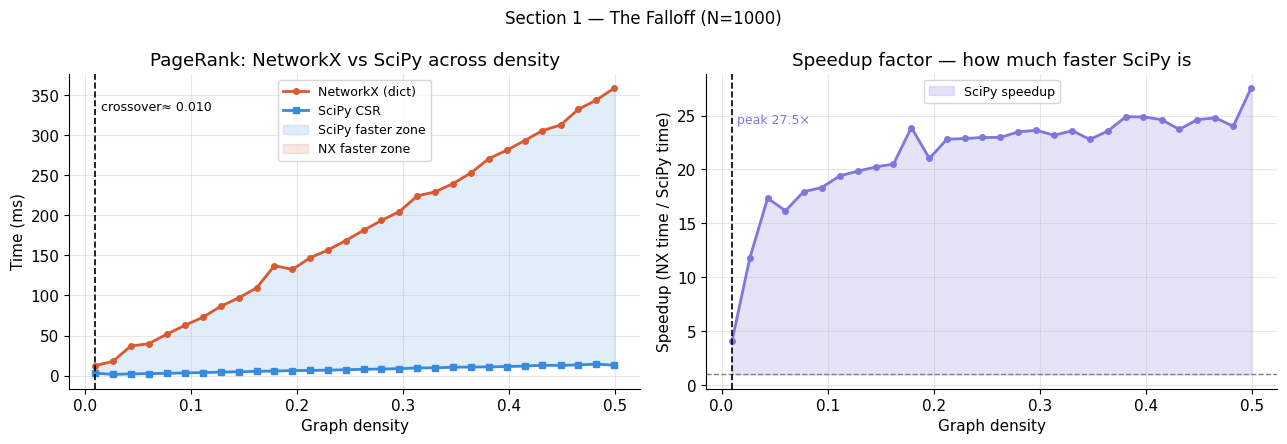

In [4]:
# ── Plot 1: timing curves with crossover marked ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(densities, nx_ms, "o-", color="#D85A30", lw=2, ms=4, label="NetworkX (dict)")
ax.plot(densities, sp_ms, "s-", color="#378ADD", lw=2, ms=4, label="SciPy CSR")
ax.fill_between(densities, nx_ms, sp_ms,
    where=(sp_ms < nx_ms), alpha=0.15, color="#378ADD", label="SciPy faster zone")
ax.fill_between(densities, nx_ms, sp_ms,
    where=(sp_ms >= nx_ms), alpha=0.15, color="#D85A30", label="NX faster zone")
ax.axvline(crossover_density, color="black", lw=1.2, linestyle="--")
ax.text(crossover_density + 0.005, ax.get_ylim()[1] * 0.88,
        f"crossover≈ {crossover_density:.3f}", fontsize=9)
ax.set_xlabel("Graph density"); ax.set_ylabel("Time (ms)")
ax.set_title("PageRank: NetworkX vs SciPy across density"); ax.legend(fontsize=9)

ax = axes[1]
speedup = nx_ms / sp_ms
ax.plot(densities, speedup, "o-", color="#7F77DD", lw=2, ms=4)
ax.axhline(1.0, color="grey", lw=1, linestyle="--")
ax.axvline(crossover_density, color="black", lw=1.2, linestyle="--")
ax.fill_between(densities, 1.0, speedup, where=(speedup > 1),
    alpha=0.2, color="#7F77DD", label="SciPy speedup")
ax.set_xlabel("Graph density"); ax.set_ylabel("Speedup (NX time / SciPy time)")
ax.set_title("Speedup factor — how much faster SciPy is"); ax.legend(fontsize=9)
ax.text(crossover_density + 0.005, speedup.max() * 0.88,
        f"peak {speedup.max():.1f}×", fontsize=9, color="#7F77DD")

plt.suptitle(f"Section 1 — The Falloff (N={N})", fontsize=12)
plt.tight_layout()
plt.savefig("s1_falloff.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 2 — Memory Falloff

Timing tells half the story. Memory pressure tells the other half.
As density rises, NetworkX's dict allocates increasingly large intermediate
structures during traversal. SciPy's CSR stays proportional to stored non-zeros.


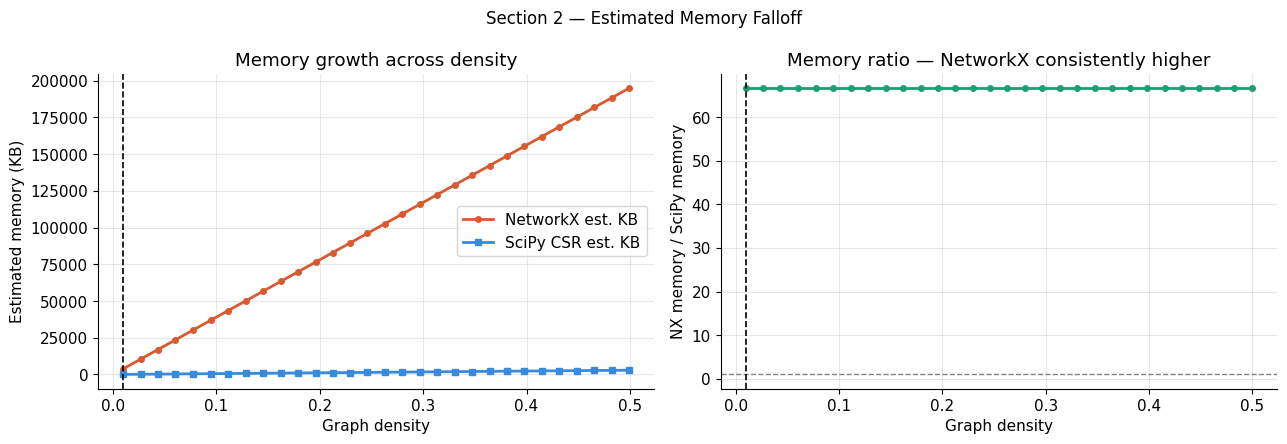

At density 0.50:
  NetworkX est: 194828.9 KB
  SciPy est:    2922.4 KB
  Ratio:        66.7×


In [5]:
nx_kb_est = np.array([e * 800 / 1024 for e in edge_counts])  # ~800 bytes per NX edge
sp_kb_est = np.array([e * 12  / 1024 for e in edge_counts])  # 12 bytes per CSR non-zero

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(densities, nx_kb_est, "o-", color="#D85A30", lw=2, ms=4, label="NetworkX est. KB")
ax1.plot(densities, sp_kb_est, "s-", color="#378ADD", lw=2, ms=4, label="SciPy CSR est. KB")
ax1.axvline(crossover_density, color="black", lw=1.2, linestyle="--")
ax1.set_xlabel("Graph density"); ax1.set_ylabel("Estimated memory (KB)")
ax1.set_title("Memory growth across density"); ax1.legend()

mem_ratio = nx_kb_est / np.maximum(sp_kb_est, 0.01)
ax2.plot(densities, mem_ratio, "o-", color="#1D9E75", lw=2, ms=4)
ax2.axhline(1.0, color="grey", lw=1, linestyle="--")
ax2.axvline(crossover_density, color="black", lw=1.2, linestyle="--")
ax2.set_xlabel("Graph density"); ax2.set_ylabel("NX memory / SciPy memory")
ax2.set_title("Memory ratio — NetworkX consistently higher")

plt.suptitle("Section 2 — Estimated Memory Falloff", fontsize=12)
plt.tight_layout()
plt.savefig("s2_memory_falloff.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"At density {densities[-1]:.2f}:")
print(f"  NetworkX est: {nx_kb_est[-1]:.1f} KB")
print(f"  SciPy est:    {sp_kb_est[-1]:.1f} KB")
print(f"  Ratio:        {mem_ratio[-1]:.1f}×")

---
## Section 3 — Does the Crossover Move with Graph Size?

The crossover density is not fixed — it shifts as N changes.
Larger graphs hit the falloff earlier because absolute edge count
grows as N² even at the same density.


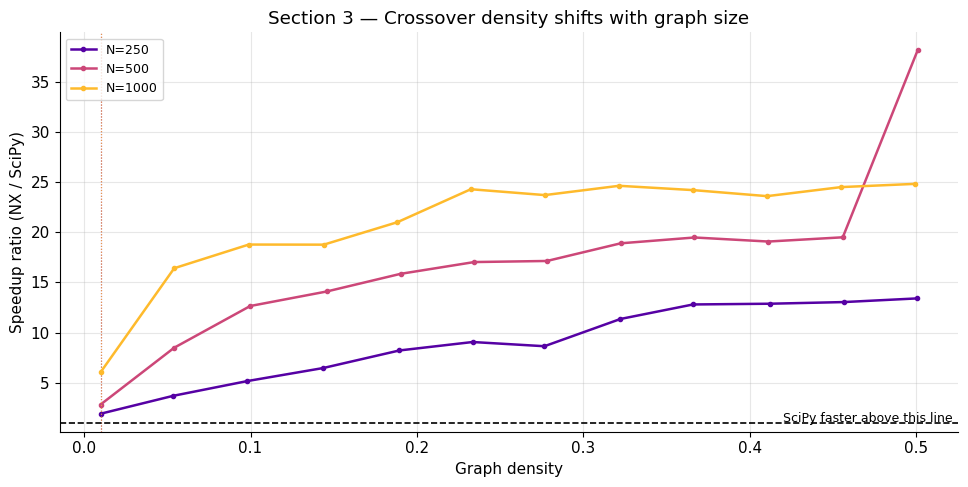

Crossover densities by graph size:
  N=250    crossover at density ≈ 0.010  (321 edges)
  N=500    crossover at density ≈ 0.010  (1,230 edges)
  N=1000   crossover at density ≈ 0.010  (4,985 edges)


In [6]:
N_vals = [250, 500, 1000]          # drop 1500 and 2000
p_fine = np.linspace(0.01, 0.50, 12)  # 12 steps instead of 20

fig, ax = plt.subplots(figsize=(10, 5))
colors_n = plt.cm.plasma(np.linspace(0.15, 0.85, len(N_vals)))
crossovers = {}

for N_i, col in zip(N_vals, colors_n):
    ratios = []
    dens   = []
    for p in p_fine:
        G = nx.erdos_renyi_graph(N_i, p, seed=42)
        A = nx.to_scipy_sparse_array(G, dtype=float, format="csr")
        t_nx = bench(nx.pagerank, G)
        t_sp = bench(scipy_pagerank, A)
        ratios.append(t_nx / t_sp)
        dens.append(nx.density(G))
        del G, A
        gc.collect()

    ratios = np.array(ratios)
    dens   = np.array(dens)
    ax.plot(dens, ratios, "o-", color=col, lw=1.8, ms=3, label=f"N={N_i}")

    idx = np.argmax(ratios > 1.0)
    if ratios[idx] > 1.0:
        crossovers[N_i] = dens[idx]
        ax.axvline(dens[idx], color=col, lw=0.8, linestyle=":", alpha=0.7)

ax.axhline(1.0, color="black", lw=1.2, linestyle="--")
ax.text(0.42, 1.04, "SciPy faster above this line", fontsize=9, color="black")
ax.set_xlabel("Graph density"); ax.set_ylabel("Speedup ratio (NX / SciPy)")
ax.set_title("Section 3 — Crossover density shifts with graph size")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("s3_size_crossover.png", dpi=150, bbox_inches="tight")
plt.show()

print("Crossover densities by graph size:")
for N_i, d in sorted(crossovers.items()):
    print(f"  N={N_i:<5}  crossover at density ≈ {d:.3f}  "
          f"({int(N_i * (N_i-1) * d / 2):,} edges)")

---
## Section 4 — The Verdict

A single chart summarising the decision boundary across all tested graph sizes.


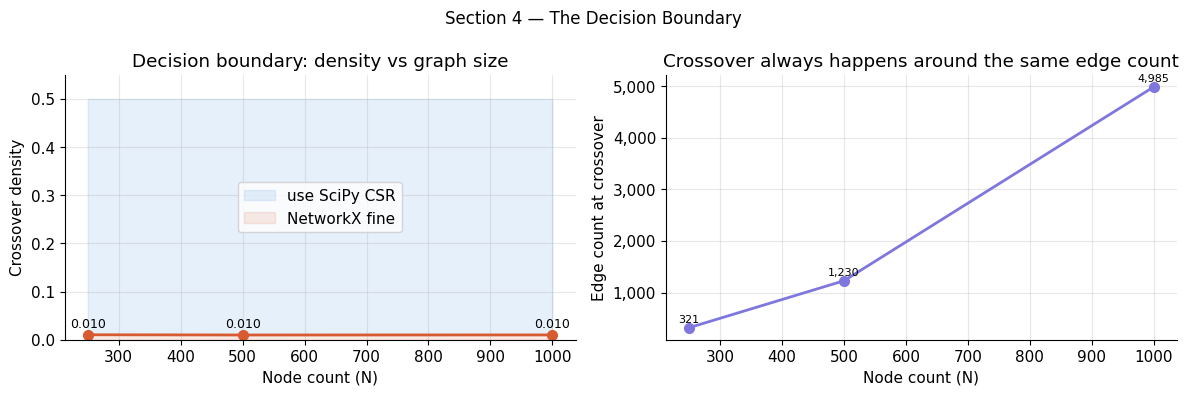

Average edge count at crossover: ~2,178
Rule of thumb: switch to SciPy when edge count exceeds ~2,178


In [7]:
if crossovers:
    ns   = sorted(crossovers.keys())
    ds   = [crossovers[n] for n in ns]
    edge_at_cross = [int(n*(n-1)*d/2) for n, d in zip(ns, ds)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(ns, ds, "o-", color="#D85A30", lw=2, ms=7)
    ax1.fill_between(ns, ds, 0.50, alpha=0.12, color="#378ADD", label="use SciPy CSR")
    ax1.fill_between(ns, 0,  ds,  alpha=0.12, color="#D85A30", label="NetworkX fine")
    ax1.set_xlabel("Node count (N)"); ax1.set_ylabel("Crossover density")
    ax1.set_title("Decision boundary: density vs graph size")
    ax1.set_ylim(0, 0.55); ax1.legend()
    for n, d in zip(ns, ds):
        ax1.text(n, d + 0.015, f"{d:.3f}", ha="center", fontsize=9)

    ax2.plot(ns, edge_at_cross, "o-", color="#7F77DD", lw=2, ms=7)
    ax2.set_xlabel("Node count (N)"); ax2.set_ylabel("Edge count at crossover")
    ax2.set_title("Crossover always happens around the same edge count")
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for n, e in zip(ns, edge_at_cross):
        ax2.text(n, e + max(edge_at_cross)*0.02, f"{e:,}", ha="center", fontsize=8)

    plt.suptitle("Section 4 — The Decision Boundary", fontsize=12)
    plt.tight_layout()
    plt.savefig("s4_verdict.png", dpi=150, bbox_inches="tight")
    plt.show()

    avg_edge_crossover = int(np.mean(edge_at_cross))
    print(f"Average edge count at crossover: ~{avg_edge_crossover:,}")
    print(f"Rule of thumb: switch to SciPy when edge count exceeds ~{avg_edge_crossover:,}")